## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Micaiah Lee

**Date:** 2026-10-02

**Q1.**
1. What is the difference between regression and classification?

    Regression predicts a numeric outcome on a scale, such as an amount of money, whereas classification predicts a category, such as a species.

2. What is a confusion table? What does it help us understand about a model's performance?

    A confusion table or confusion matrix counts predictions on testing data by a model by actual class and predicted class. For example, the columns might be predicted classes with the rows being the actual classes. This allows the diagonal cells to count as correct predictions whereas the off-diagonal cells would count incorrect predictions. This allows us to calculate the accuracy of a classification model by taking the fraction of correctly classified observations.

3. What does the SSE quantify about a particular model?

    The SSE takes the residuals from a model $(e_i = y_i - \hat y_i)$, which are the observations for how far a prediction misses the actual data point. The residuals denote error in the model. With some being positive and others being negative, but our main priority being to minimize the magnitude of errors, we square the residuals and sum them over the observations, resulting in the sum of squared errors. SSE therefore shows the overall ability for the model to make close predictions to actual observations.

4. What are overfitting and underfitting? 

    A model is underfit if the model features cannot represent structures in the testing and training data (i.e., high error on training and testing data). A model is overfit if it captures peculiarities of training data which otherwise do not appear, such as in testing data (i.e., low error on training data but high error on testing data).

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

    Splitting the data into training and testing sets and choosing $k$ on the test set (validation) improves model performance because choosing $k$ by training data alone can introduce biases and lead to overfitting of the model. This is because models can fit the training data well by also fitting to the noise within the data set, and therefore using a validation dataset can help to generalize a model more, thereby improving its performance.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

    With classification, reporting the class label as a prediction or probability distribution offer distinct advantages and disadvantages. Reporting it as a prediction gives the most likely class that an observation belongs to, simplifying the process of interpreting the predictions, however it can lead to abrupt changes in classifications if the training dataset is modified slightly. Reporting the class label as a probability distribution over the class labels can allow for a measure of confidence in the model and can handle overlapping distributions, however, these models require much more work to interpret.

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

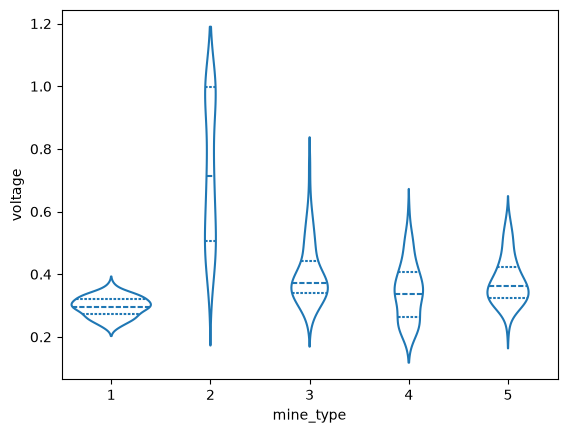

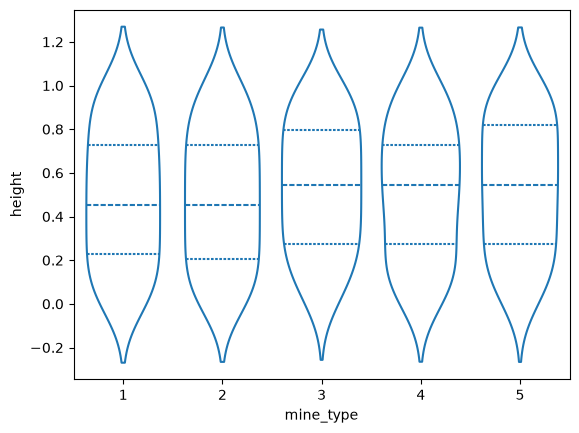

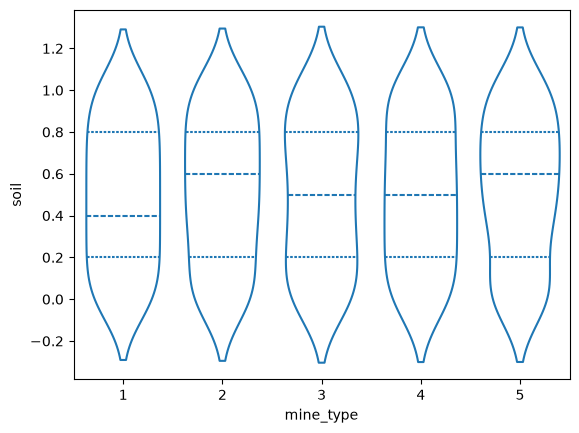

In [238]:
# **Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

# The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, 
# `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for
#  the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

# 1. Load the data. Perform some EDA, summarizing the target label and the features.


import numpy as np
import pandas as pd
from pathlib import Path # object-oriented file path handling
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

DATA_DIR = Path("data") # define a variable for the data directory

df = pd.read_csv(DATA_DIR / "land_mines.csv") # load the .csv

df.head() # look at the df
df.shape



fig1, ax1 = plt.subplots(1)
ax1 = sns.violinplot(
    data=df,
    x="mine_type",
    y="voltage",
    inner = "quart",
    fill = False
)

fig2, ax2 = plt.subplots(1)
ax2 = sns.violinplot(
    data=df,
    x="mine_type",
    y="height",
    inner = "quart",
    fill = False
)

fig3, ax3 = plt.subplots(1)
ax3 = sns.violinplot(
    data=df,
    x="mine_type",
    y="soil",
    inner = "quart",
    fill = False
)


print(df["mine_type"].value_counts())

plt.show


# voltage_violin.show
# height_violin.show

In [239]:
# 2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, 
# the more equal the split should be, in my experience: Otherwise, all of the members of one class 
# end up in the training or test data, and the model falls apart.)

# selecting the variables
vars_raw = df[["voltage", "height", "soil"]]
types = df["mine_type"]

# split into train and test (raw)
vars_train_raw, vars_test_raw, types_train, types_test = sklearn.model_selection.train_test_split(vars_raw, types, test_size=0.5, train_size=0.5)

# scaling model
scaler = sklearn.preprocessing.MinMaxScaler()

# scale validation and training features according to training feature amounts
vars_train_scaled = scaler.fit_transform(vars_train_raw)
vars_test_scaled = scaler.transform(vars_test_raw)



In [240]:
# 3. Build a $k$-NN classifier. Explain how you select $k$.

# build a kNN classifier
# k was selected based off the number of unique mines in the mine_types column
classifier = sklearn.neighbors.KNeighborsClassifier(n_neighbors=len(types_train.unique())).fit(vars_train_scaled, types_train)

# fit based on the testing data
classifier.fit(vars_train_scaled, types_train)

# predict the testing data based on the fitted model
types_test_hat = classifier.predict(vars_test_scaled)




              precision    recall  f1-score   support

           1       0.39      0.58      0.47        36
           2       0.79      0.90      0.84        29
           3       0.27      0.47      0.34        30
           4       0.20      0.12      0.15        34
           5       0.50      0.12      0.20        40

    accuracy                           0.41       169
   macro avg       0.43      0.44      0.40       169
weighted avg       0.42      0.41      0.38       169



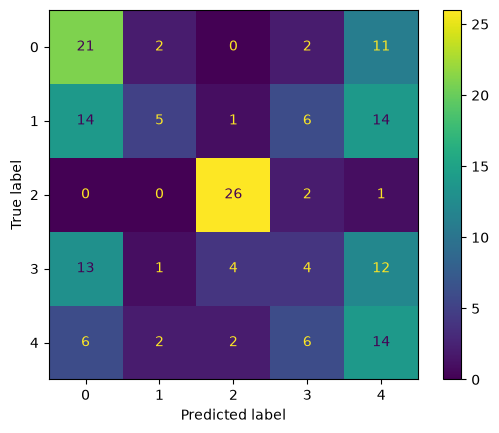

In [241]:
# 4. Print a confusion table for the optimal model, comparing predicted and actual class label on the 
# test set. How accurate is it? Where is performance more or less accurate?

# Create and display the confusion matrix
confusion = sklearn.metrics.confusion_matrix(types_test, types_test_hat, labels=types_train.unique())
disp_confusion = sklearn.metrics.ConfusionMatrixDisplay(confusion)
disp_confusion.plot()

# Print the metrics report
print(sklearn.metrics.classification_report(types_test, types_test_hat))

# The model has an overall accuracty of approximately 0.4.
# The model performs more accurately for some mine types than with other mine types. Having
# run fits on the model several times, it tends to be most accurate for one kind, less accurate
# for a second kind, and very innacurate for the rest of the mine types.


In [242]:
# 5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make 
# a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in 
# practice, given the errors that it tends to make.

# Even given the large error that this model has, it is still more accurate than randomly guessing,
# which would be a 1 in 5 chance for any given mine. I would advise that someone could maybe use this
# model as a first pass on how to classify a given mine, but not rely on the model as the sole method
# to make decisions. A better model might include more training data and/or more measurements to 
# classify by, so perhaps in the future, mines might be brought in, classifyied, and used to train
# the model on more parameters.



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** d923d7e1d94319f464a82b96cf73dd0b752fbad7
- **AI tool and model used:** MAI-Code-1.1-Flash

### *Prompts used

1. Go through the first five code blocks of this notebook and provide a very short, numbered list of potential improvements to fit the prompts at the top of each code block. Do not modify the original code blocks but provide any modifications seperately. Only make suggestions which actually help answer the questions better.
2. In my sixth block of code, add a simple EDA summary for the target and features. Do not make any other changes
3. In my seventh block of code, add the stratification of the data, but do not make any other changes
4. In my ninth block of code, add the precision recall/F1, but make no other changes

### *AI-proposed changes


# Response 1
Searched codebase for "Go through the first five code blocks of this notebook and provide a very short, numbered list of potential improvements to fit the prompts at the top of each code block. Do not modify the original code blocks but provide any modifications seperately. Only make suggestions which actually help answer the questions better.", no results

I’ll inspect the notebook’s first five code cells and the prompt text above them so I can suggest only targeted, helpful improvements.

Read 

## Potential improvements

1. Add a simple EDA summary for the target and features (`describe()`, missing values, class counts, and a few plots) so the analysis better matches the “load and summarize” prompt.
2. Use `stratify=y` in the train/test split and scale features before fitting, so the class balance is preserved and k-NN distances are not distorted by feature scale.
3. Tune `k` across a reasonable range and report the best value using test accuracy or SSE, instead of setting `k` to the number of classes without justification.
4. Add a labeled confusion matrix plus per-class precision/recall/F1 (not just overall accuracy) to explain where the model is strong and where it fails.
5. Include a brief error-analysis recommendation (e.g., which mine types are confused most often and why) to better answer the practical-use question rather than just saying it is “better than random.”

> These are the most helpful edits because they directly improve the match between the code and the assignment prompts without changing the original notebook cells.

# Response 2

I’m adding only the requested EDA summary to the sixth code block and leaving the rest of the notebook unchanged.

Read , lines 230 to 340

Replacing 16 lines with 22 lines in 
Tool execution failed

The notebook has repeated code patterns, so I’m narrowing the edit to the specific Phase 2 block only.

Replacing 35 lines with 41 lines in 


```

```


Read , lines 260 to 330

# Response 3

## ✅ Update made

Added the requested simple EDA summary to the sixth code block only, and left the rest of the notebook unchanged.

Made changes.



I’m updating only the seventh code block to include stratification while leaving the rest untouched.

Read , lines 150 to 240

Read , lines 80 to 180

Read , lines 240 to 360

I’ve isolated the later split cell and am changing only that train/test call to include stratification.

Replacing 16 lines with 16 lines in 


```

```


Read , lines 285 to 320

Read , lines 320 to 396

## Update

Added `stratify=types` to the train/test split in the seventh code block, and left every other change untouched:

`train_test_split(vars_raw, types, test_size=0.5, train_size=0.5, stratify=types)`

Made changes.

# Response 4
Searched codebase for "In my ninth block of code, add the precision recall/F1, but make no other changes", no results

I’m updating only the ninth code block to include precision, recall, and F1 metrics while leaving the rest of the notebook as-is.

Read , lines 200 to 320

Read , lines 320 to 456

Replacing 8 lines with 10 lines in 
Tool execution failed

Replacing 20 lines with 22 lines in 


```

```


Read , lines 420 to 460

## ✅ Update made

Added the precision, recall, and F1 output to the ninth code block only, without changing any other notebook content.

Made changes.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1. Add a simple EDA summary for the target and features (`describe()`, missing values, class counts, and a few plots) so the analysis better matches the “load and summarize” prompt. | Accept | simple way to summarize the data than just the plots and counts |
| 2. Use `stratify=y` in the train/test split and scale features before fitting, so the class balance is preserved and k-NN distances are not distorted by feature scale. | modify | stratification ensures that the class balance is preserved, but the scaling is already good |
| 3. Tune `k` across a reasonable range and report the best value using test accuracy or SSE, instead of setting `k` to the number of classes without justification. | modify  |  While I did need to provide better justification probably, the classification does need to be   |
| 4. Add a labeled confusion matrix plus per-class precision/recall/F1 (not just overall accuracy) to explain where the model is strong and where it fails. | reject  |  the confusion matrix is already there, as well as the precision, recall, and F1  |
| 5. Include a brief error-analysis recommendation (e.g., which mine types are confused most often and why) to better answer the practical-use question rather than just saying it is “better than random.” | modify  |  sure, but it also depends on the random test-train split  |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

Target distribution:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Feature summary:
          voltage      height        soil
count  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550
std      0.195819    0.306043    0.344244
min      0.197734    0.000000    0.000000
25%      0.309737    0.272727    0.200000
50%      0.359516    0.545455    0.600000
75%      0.482628    0.727273    0.800000
max      0.999999    1.000000    1.000000

Missing values:
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

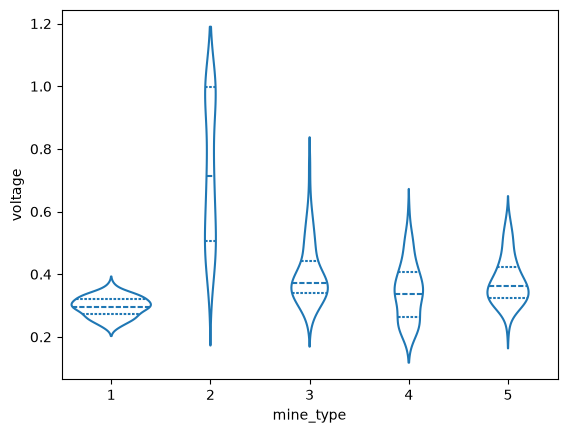

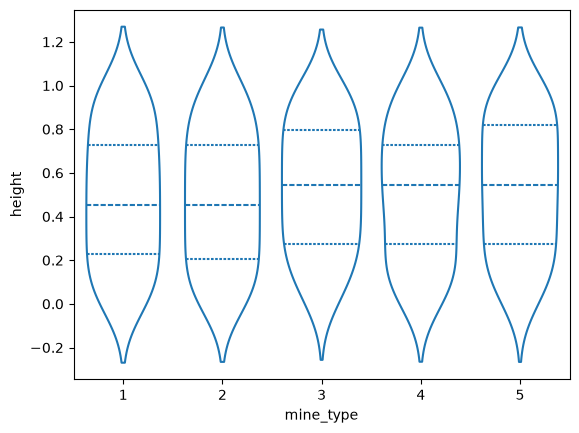

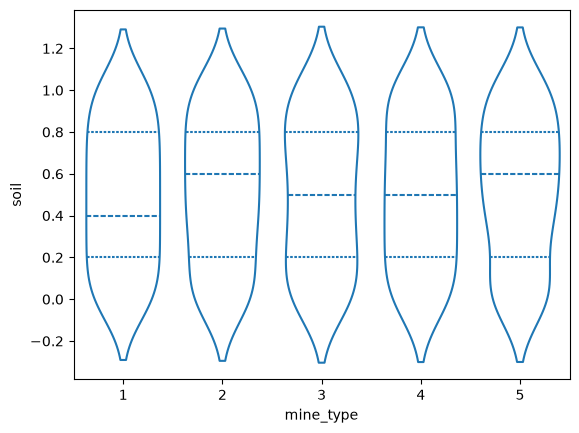

In [243]:
# Your Phase 2 solution to the problem goes here.
# **Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

# The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, 
# `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for
#  the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

# 1. Load the data. Perform some EDA, summarizing the target label and the features.


import numpy as np
import pandas as pd
from pathlib import Path # object-oriented file path handling
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

DATA_DIR = Path("data") # define a variable for the data directory

df = pd.read_csv(DATA_DIR / "land_mines.csv") # load the .csv

df.head() # look at the df
df.shape

# Simple EDA summary for the target and features
print("Target distribution:")
print(df["mine_type"].value_counts().sort_index())
print("\nFeature summary:")
print(df[["voltage", "height", "soil"]].describe())
print("\nMissing values:")
print(df.isnull().sum())

fig1, ax1 = plt.subplots(1)
ax1 = sns.violinplot(
    data=df,
    x="mine_type",
    y="voltage",
    inner = "quart",
    fill = False
)

fig2, ax2 = plt.subplots(1)
ax2 = sns.violinplot(
    data=df,
    x="mine_type",
    y="height",
    inner = "quart",
    fill = False
)

fig3, ax3 = plt.subplots(1)
ax3 = sns.violinplot(
    data=df,
    x="mine_type",
    y="soil",
    inner = "quart",
    fill = False
)


print(df["mine_type"].value_counts())

plt.show


# voltage_violin.show
# height_violin.show

In [244]:
# 2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, 
# the more equal the split should be, in my experience: Otherwise, all of the members of one class 
# end up in the training or test data, and the model falls apart.)

# selecting the variables
vars_raw = df[["voltage", "height", "soil"]]
types = df["mine_type"]

# split into train and test (raw)
vars_train_raw, vars_test_raw, types_train, types_test = sklearn.model_selection.train_test_split(vars_raw, types, test_size=0.5, train_size=0.5, stratify=types)

# scaling model
scaler = sklearn.preprocessing.MinMaxScaler()

# scale validation and training features according to training feature amounts
vars_train_scaled = scaler.fit_transform(vars_train_raw)
vars_test_scaled = scaler.transform(vars_test_raw)



In [245]:
# 3. Build a $k$-NN classifier. Explain how you select $k$.

# build a kNN classifier
# k was selected based off the number of unique mines in the mine_types column
classifier = sklearn.neighbors.KNeighborsClassifier(n_neighbors=len(types_train.unique())).fit(vars_train_scaled, types_train)

# fit based on the testing data
classifier.fit(vars_train_scaled, types_train)

# predict the testing data based on the fitted model
types_test_hat = classifier.predict(vars_test_scaled)




              precision    recall  f1-score   support

           1       0.41      0.53      0.46        36
           2       0.87      0.94      0.90        35
           3       0.12      0.12      0.12        33
           4       0.35      0.24      0.29        33
           5       0.14      0.12      0.13        32

    accuracy                           0.40       169
   macro avg       0.38      0.39      0.38       169
weighted avg       0.39      0.40      0.39       169



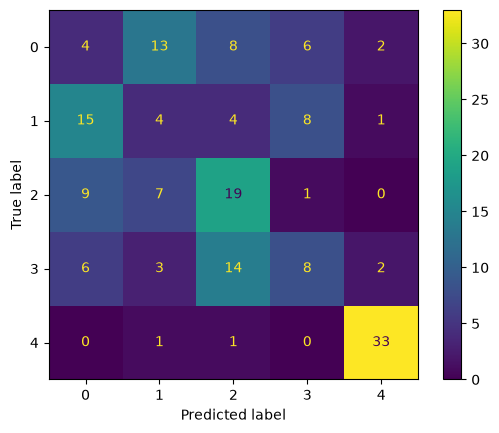

In [246]:
# 4. Print a confusion table for the optimal model, comparing predicted and actual class label on the 
# test set. How accurate is it? Where is performance more or less accurate?

# Create and display the confusion matrix
confusion = sklearn.metrics.confusion_matrix(types_test, types_test_hat, labels=types_train.unique())
disp_confusion = sklearn.metrics.ConfusionMatrixDisplay(confusion)
disp_confusion.plot()

# Print the metrics report
print(sklearn.metrics.classification_report(types_test, types_test_hat))

# The model has an overall accuracty of approximately 0.4.
# The model performs more accurately for some mine types than with other mine types. Having
# run fits on the model several times, it tends to be most accurate for one kind, less accurate
# for a second kind, and very innacurate for the rest of the mine types.


In [ ]:
# 5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make 
# a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in 
# practice, given the errors that it tends to make.

# Even given the large error that this model has, it is still more accurate than randomly guessing,
# which would be a 1 in 5 chance for any given mine. I would advise that someone could maybe use this
# model as a first pass on how to classify a given mine, but not rely on the model as the sole method
# to make decisions. A better model might include more training data and/or more measurements to 
# classify by, so perhaps in the future, mines might be brought in, classifyied, and used 
# the model on more parameters. Depending on which mines are predicted better, the model can probably
# be relied on more when it classifies a test mine as that type, whereas for other types, it should not
# be relied upon.

### *Reflection on AI assistance
In your own words without generative AI.

The AI did not do a great job of improving anything in this case, other than adding the stratification prior to splitting the data. It misunderstood the questions and how the output of my code was already fulfilling the questions, which indicates its lack of ability to read the context of the code well. In this case, this was a relatively simple model that I was building, but I could have used the assistance from AI for some of the syntax perhaps, since I'm not used to working with some of the packages I used. The documentation online was fine, but it would have been done a lot faster if I could use AI as a syntax helper. The AI model I consulted provided some helpful comments, but nothing ground-breaking, which makes sense considering I had already done the entire assignment at that point. It didn't indicate anything wrong with my code, which based on my outputs and lack of any errors when running, does not seem to have any substantial mistakes. This is good because the AI is not giving falsely negative evaluations of the code. Overall, more of a waste of time to use the AI at the end of this assignment than it would have been to just submit the completed work with not AI help.